# Embedding space analysis

This notebook allows to visualize molecules in the embedding space and generally analyze the embedding space properties of different modalities.

In [6]:
import os
from dotenv import load_dotenv

load_dotenv()

PROCESSED_DIR = os.environ.get("PROCESSED_DIR")
BASE_DIR = os.environ.get("BASE_DIR")

Ensure to select data points that have embeddings for all modalities

In [10]:
import pandas as pd
from pathlib import Path

def col_to_prefix(col):
    for suffix in ["_embedding_path", "_descriptors_path", "_path"]:
        if col.endswith(suffix):
            return col[: -len(suffix)]
    return col

file = "merged_data_deduplicated_with_benchmarks_log_final"
file_path = f"{PROCESSED_DIR}/{file}.csv"

# Modalities to visualize
modality_columns = [
    "bioxmol_embedding_path",
    "boltz_embedding_path",
    "uma_embedding_path",
    "cloome_embedding_path",
    "moe_descriptors_path",
    "xtb_targets_path",
    "nabla_targets_path",
    "chemgpt_embedding_path",
    "pcba_targets_path",
]

modality_prefixes = {col: col_to_prefix(col) for col in modality_columns}

# Load data
lookup_df = pd.read_csv(file_path)

# Select top N rows with highest modality coverage
N = 1000
availability = lookup_df[modality_columns].notna().sum(axis=1)
lookup_df["_modality_count"] = availability
top_df = lookup_df.nlargest(N, "_modality_count")
valid_indices = top_df.index.tolist()

print(f"\nSelected {len(valid_indices)} samples")
print(f"Modality coverage distribution:")
print(top_df["_modality_count"].value_counts().sort_index(ascending=False).to_string())
print(f"\nMin coverage: {top_df['_modality_count'].min()}/{len(modality_columns)}")
print(f"Max coverage: {top_df['_modality_count'].max()}/{len(modality_columns)}")

# Show which modalities are available for the selected subset
for col in modality_columns:
    prefix = modality_prefixes[col]
    n_avail = top_df[col].notna().sum()
    print(f"  {prefix}: {n_avail}/{N} available")

/tmp/ipykernel_657428/3397588790.py:32: DtypeWarning: Columns (2,3,4,5,6,7,9,24,27,29,30,68) have mixed types. Specify dtype option on import or set low_memory=False.
  lookup_df = pd.read_csv(file_path)



Selected 1000 samples
Modality coverage distribution:
_modality_count
9    838
8    162

Min coverage: 8/9
Max coverage: 9/9
  bioxmol: 1000/1000 available
  boltz: 969/1000 available
  uma: 1000/1000 available
  cloome: 1000/1000 available
  moe: 1000/1000 available
  xtb_targets: 1000/1000 available
  nabla_targets: 884/1000 available
  chemgpt: 1000/1000 available
  pcba_targets: 985/1000 available


Load embeddings from disk

In [11]:
import torch
import numpy as np

arrs = []
names = []
dir_path = Path(f"{BASE_DIR}/data/processed/tensors_{file}")

for col in modality_columns:
    prefix = modality_prefixes[col]
    available_mask = top_df[col].notna()
    
    embeddings = []
    for idx in valid_indices:
        if pd.notna(lookup_df.loc[idx, col]):
            t = torch.load(f"{dir_path}/{prefix}_data_{idx}.pt", weights_only=True)
            if t.dim() > 1:
                t = t.mean(0)  # e.g. UMA per-atom mean pool
            embeddings.append(t.numpy().flatten())
        else:
            embeddings.append(None)
    
    dim = next(e.shape[0] for e in embeddings if e is not None)
    embeddings = [e if e is not None else np.full(dim, np.nan) for e in embeddings]
    
    arr = np.stack(embeddings)
    arrs.append(arr)
    names.append(prefix.replace("_", " ").title())
    
    n_valid = (~np.isnan(arr[:, 0])).sum()
    print(f"{prefix}: shape={arr.shape}, valid={n_valid}/{len(valid_indices)}")

bioxmol: shape=(1000, 1024), valid=1000/1000
boltz: shape=(1000, 384), valid=969/1000
uma: shape=(1000, 128), valid=1000/1000
cloome: shape=(1000, 512), valid=1000/1000
moe: shape=(1000, 227), valid=1000/1000
xtb_targets: shape=(1000, 7), valid=1000/1000
nabla_targets: shape=(1000, 17), valid=884/1000
chemgpt: shape=(1000, 2048), valid=1000/1000
pcba_targets: shape=(1000, 1328), valid=21/1000


### Plotting

Some helpers

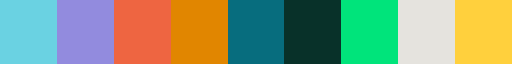

In [12]:
from rdkit import Chem
from rdkit.Chem import Draw
from colors import bi_discrete_cmap


def mol_to_img(smiles, size=100):
    """Convert SMILES to a RDKit PNG image array."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    drawer = Draw.MolToImage(mol, size=(size, size))
    return drawer


bi_discrete_cmap

UMAP and randomly visualizing molecules

Highlighting indices: [4290515, 4276954, 4341655, 4295316, 4276960]
(1000, 1024)
(1000, 384)
(1000, 128)
(1000, 512)
(1000, 227)
(1000, 7)
(1000, 17)
(1000, 2048)


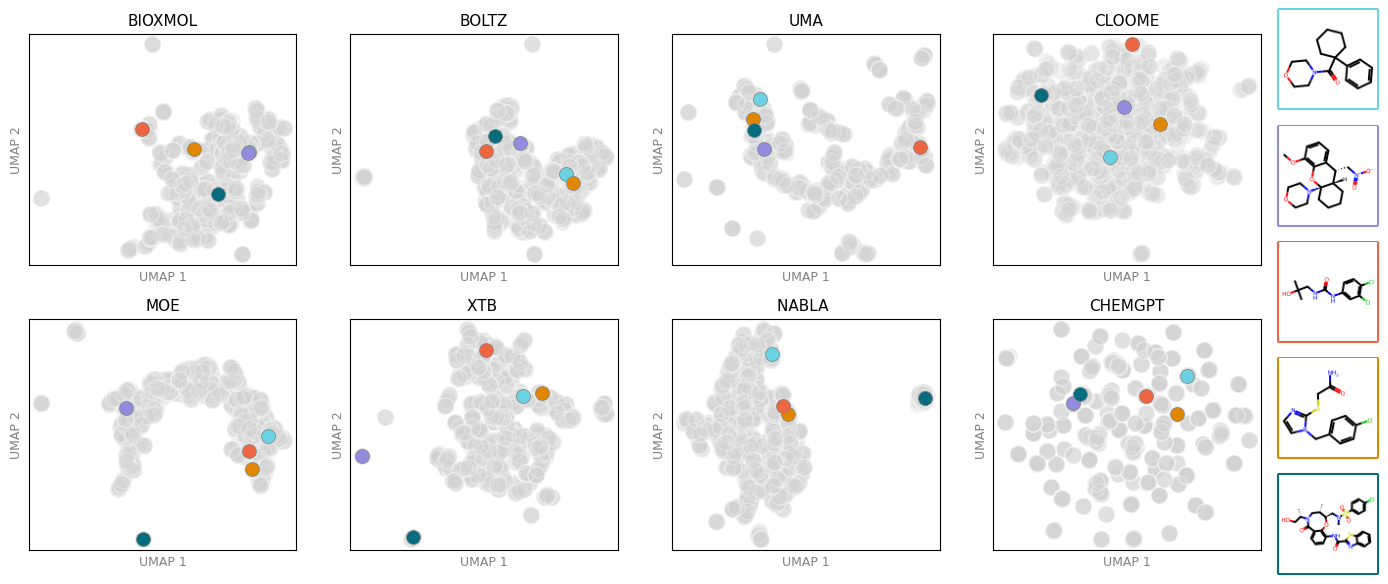

In [14]:
import random
import umap
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.gridspec import GridSpec


num_highlights = 5
highlight_indices = random.sample(valid_indices, num_highlights)
print("Highlighting indices:", highlight_indices)

# Assign each highlighted index a unique color
highlight_cmap = bi_discrete_cmap
highlight_colors = {
    idx: highlight_cmap(i % 10) for i, idx in enumerate(highlight_indices)
}

# Figure config
cols = 4 if len(arrs) > 4 else 2
fig = plt.figure(figsize=(3 * cols + 2, 6))
gs = GridSpec(2, cols + 1, figure=fig, width_ratios=[1]*cols + [0.1])

# Create normal subplot axes
axes = []
for r in range(2):
    for c in range(cols):
        ax = fig.add_subplot(gs[r, c])
        axes.append(ax)

# UMAP
for ax, arr, name in zip(axes, arrs, names):
    print(arr.shape)

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=3,
        min_dist=0.1,
        metric="euclidean"
    )
    X_umap = reducer.fit_transform(np.nan_to_num(arr))

    background_mask = [idx not in highlight_indices for idx in valid_indices]
    ax.scatter(
        X_umap[background_mask, 0],
        X_umap[background_mask, 1],
        s=150,
        color="lightgrey",
        edgecolor="white",
        linewidth=1,
        alpha=0.3,
        zorder=1,
    )

    # Highlighted colored markers
    for i, idx in enumerate(valid_indices):
        if idx in highlight_indices:
            ax.scatter(
                X_umap[i, 0],
                X_umap[i, 1],
                s=100,
                color=highlight_colors[idx],
                edgecolor="grey",
                linewidth=0.5,
                zorder=3,
            )

    ax.set_title(name.upper().replace("TARGETS", ""), fontsize=11)
    ax.set_xlabel("UMAP 1", fontsize=9, color="grey")
    ax.set_ylabel("UMAP 2", fontsize=9, color="grey")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(alpha=0.3)


# Legend molecules
legend_ax = fig.add_subplot(gs[:, -1])
legend_ax.axis("off")

# Vertical stacking of images
y_positions = np.linspace(0.95, 0.05, len(highlight_indices))

for ypos, idx in zip(y_positions, highlight_indices):
    smiles = lookup_df.loc[idx, "smiles"]
    img = mol_to_img(smiles, size=100)

    if img is None:
        continue

    imagebox = OffsetImage(img, zoom=0.7)

    ab = AnnotationBbox(
        imagebox,
        (0.5, ypos),
        xycoords="axes fraction",
        frameon=True,
        pad=0.1,
        bboxprops=dict(
            edgecolor=highlight_colors[idx],
            linewidth=1.5,
            boxstyle="round,pad=0.1"
        ),
    )
    legend_ax.add_artist(ab)

plt.tight_layout()
# Save the figure
plt.savefig("figures/umap_highlighted_molecules.png", dpi=300, bbox_inches="tight")
plt.show()

### Centered Kernel Alignment

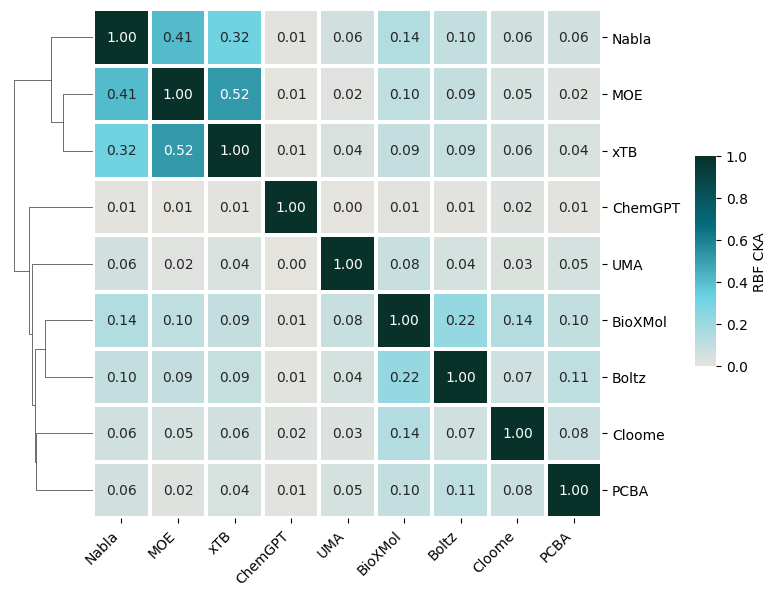

In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform, pdist
from sklearn.metrics.pairwise import rbf_kernel

import importlib
import colors
importlib.reload(colors)
from colors import bi_continuous_cmap


DISPLAY_NAMES = {
    "bioxmol": "BioXMol",
    "boltz": "Boltz",
    "uma": "UMA",
    "cloome": "Cloome",
    "moe": "MOE",
    "xtb": "xTB",
    "nabla": "Nabla",
    "chemgpt": "ChemGPT",
    "pcba": "PCBA",
}


def mean_impute(X):
    """Replace NaNs with the per-column mean; all-NaN columns become 0."""
    X = np.asarray(X, dtype=np.float64).copy()
    valid = ~np.isnan(X)
    counts = valid.sum(axis=0)
    col_mean = np.divide(
        np.nansum(X, axis=0), counts,
        out=np.zeros(X.shape[1]), where=counts > 0,
    )
    nan_rows, nan_cols = np.where(~valid)
    X[nan_rows, nan_cols] = np.take(col_mean, nan_cols)
    return X


def center_gram(K):
    """Double-center a Gram/kernel matrix (O(n^2))."""
    m = K.mean(axis=0, keepdims=True)
    return K - m - m.T + K.mean()


def gram(X, kernel):
    """Linear or RBF kernel Gram matrix (RBF uses the median-distance bandwidth)."""
    if kernel == "linear":
        return X @ X.T
    sq = pdist(X, "sqeuclidean")
    sigma2 = np.median(sq) + 1e-12
    return rbf_kernel(X, gamma=1.0 / (2.0 * sigma2))


def cka_matrix(arrays, kernel, eps=1e-12):
    """Pairwise CKA similarity matrix for a list of representations."""
    centered = [center_gram(gram(X, kernel)) for X in arrays]
    n = len(centered)
    M = np.eye(n)
    for i in range(n):
        for j in range(i + 1, n):
            hsic = np.sum(centered[i] * centered[j])
            denom = np.sqrt(np.sum(centered[i] ** 2) * np.sum(centered[j] ** 2)) + eps
            M[i, j] = M[j, i] = hsic / denom
    return M


def plot_cka(M, labels, title):
    df = pd.DataFrame(M, index=labels, columns=labels)
    # Cluster modalities on their CKA distance (1 - CKA).
    link = linkage(squareform(1 - M, checks=False), method="ward")
    g = sns.clustermap(
        df,
        row_linkage=link,
        col_linkage=link,
        cmap=bi_continuous_cmap,
        vmin=0,
        vmax=1,
        annot=True,
        fmt=".2f",
        linewidths=1.5,
        linecolor="white",
        figsize=(7, 7),
        dendrogram_ratio=(0.14, 0.14),
        cbar_pos=(1.0, 0.35, 0.03, 0.3),
        cbar_kws={"label": title},
    )
    g.ax_col_dendrogram.set_visible(False)
    g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha="right")
    g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
    
    # Save figure
    plt.savefig(f"figures/cka_{title.lower().replace(' ', '_')}.png", dpi=300, bbox_inches="tight")
    plt.show()


labels = [DISPLAY_NAMES.get(name.lower().split()[0], name) for name in names]
arrs_imputed = [mean_impute(arr) for arr in arrs]

# Linear CKA and its nonlinear (RBF-kernel) counterpart
# plot_cka(cka_matrix(arrs_imputed, "linear"), labels, "Linear CKA")
plot_cka(cka_matrix(arrs_imputed, "rbf"), labels, "RBF CKA")